# Rotational probability-current test

This notebook tests whether the single-particle trajectories show evidence for a persistent **circulating probability current**. Such a curl-like current is complementary to the radial source–sink current tested in `divergence_test.ipynb`.

For every in-time trajectory step, the signed swept-area increment is calculated using the midpoint convention,

$$
a_i = \bar{x}_i\,\Delta y_i - \bar{y}_i\,\Delta x_i,
$$

and summarized as

$$
\Omega = \frac{\langle a_i\rangle}{2\,\Delta t\,\langle \bar r_i^2\rangle}.
$$

An equilibrium process has no persistent directional current and should yield $\Omega\approx0$. The estimator is calibrated using the same condensate potential as the divergence notebook, with an added rotational drift of imposed rate $\Omega_0$ as a positive control.


## Reproducibility and expected repository layout

Run this notebook from the repository root with `analysis_AllData.py`, this notebook, and the `AllData/` directory present. The expected trajectory format and Rad51 segmentation convention are identical to `divergence_test.ipynb` and `LineDistance_Stats.ipynb`.

All simulation seeds are fixed. The experimental analysis uses exactly the same `areal_current()` estimator that is validated in the simulation section.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from scipy import stats

from analysis_AllData import MIN_TOTAL, segment_foci

# Optional journal-specific plotting style.
STYLE_FILE = Path("biophysical_journal.mplstyle")
if STYLE_FILE.exists():
    plt.style.use(STYLE_FILE)

SEED = 0
DATA_ROOT = (Path.cwd() / "AllData").resolve()

# condition -> (subdirectory, filename pattern, frame interval [s])
DATASETS = {
    "Rad52": ("Rad52", "Cell*.txt", 0.02),
    "TwoDSB": ("TwoDSB", "Cell*.txt", 0.02),
    "SUMO": ("SUMO", "Cell*.txt", 0.02),
    "Rad51": ("Rad51", "Cell*.txt", 0.03),
    "Rfa1": ("Rfa1", "Cell*.txt", 0.02),
}

SEGMENT_DATASETS = {"Rad51"}
PRETTY_NAMES = {
    "Rad52": "Rad52 (1 DSB)",
    "TwoDSB": "Rad52 (2 DSB)",
    "SUMO": "Rad52-SUMO",
    "Rad51": "Rad51",
    "Rfa1": "Rfa1",
}


MIN_STEPS = 5
TIME_TOLERANCE = 1e-3  # [s]


## 1. Rotating-condensate calibration model

The latent motion is overdamped diffusion in a radial sigmoidal potential. The positive control adds the deterministic rotational drift

$$
(\dot x,\dot y)_\mathrm{rot}=(-\Omega_0 y,\Omega_0 x).
$$

`Omega0 = 0` defines the equilibrium null; positive `Omega0` produces counter-clockwise circulation. Localization noise is added after simulation.


In [2]:
@njit
def _simulate_rotating_condensate_nb(
    uniform,
    omega0,
    n_tracks,
    D,
    dt,
    frame_interval,
    sigma,
    focus_radius,
    potential_depth,
    beta,
    nucleus_radius,
    seed,
):
    """Numba implementation of the radial condensate with rotational drift."""
    np.random.seed(seed)
    noise_amplitude = np.sqrt(2 * D * dt)
    output = np.empty((n_tracks * 50, 4))
    row = 0

    for trajectory_id in range(n_tracks):
        length = np.random.randint(10, 50)

        while True:
            radius = nucleus_radius * np.sqrt(np.random.random())
            theta = 2 * np.pi * np.random.random()
            x = radius * np.cos(theta)
            y = radius * np.sin(theta)
            if uniform:
                break
            switch = 1.0 / (1.0 + np.exp(-beta * (radius - focus_radius)))
            if np.random.random() < np.exp(-potential_depth * switch):
                break

        xs = np.empty(length)
        ys = np.empty(length)
        times = np.empty(length)
        xs[0], ys[0], times[0] = x, y, 0.0
        t = 0.0
        frame = 1
        n = 1

        while n < length:
            radius = np.sqrt(x * x + y * y) + 1e-12
            switch = 1.0 / (1.0 + np.exp(-beta * (radius - focus_radius)))
            radial_drift = -D * potential_depth * beta * switch * (1.0 - switch)
            dx = (
                radial_drift * (x / radius) - omega0 * y
            ) * dt + noise_amplitude * np.random.normal()
            dy = (
                radial_drift * (y / radius) + omega0 * x
            ) * dt + noise_amplitude * np.random.normal()
            x += dx
            y += dy

            if np.sqrt(x * x + y * y) > nucleus_radius:
                x -= dx
                y -= dy

            t += dt
            if t > frame * frame_interval:
                xs[n], ys[n], times[n] = x, y, t
                frame += 1
                n += 1

        for i in range(length):
            output[row, 0] = trajectory_id
            output[row, 1] = xs[i] + np.random.normal() * sigma
            output[row, 2] = ys[i] + np.random.normal() * sigma
            output[row, 3] = times[i]
            row += 1

    return output[:row]


def simulate_rotating_condensate(
    mode="eq",
    omega0=0.0,
    n_tracks=30,
    D=0.1,
    dt=1e-4,
    frame_interval=0.02,
    sigma=0.025,
    focus_radius=0.2,
    potential_depth=3.0,
    beta=200.0,
    nucleus_radius=0.5,
    seed=SEED,
):
    """Simulate equilibrium or uniformly initialized condensate trajectories.

    Parameters
    ----------
    omega0 : float
        Imposed rotational drift rate [rad/s]. ``omega0=0`` is the equilibrium null.
    """
    if mode not in {"eq", "uniform"}:
        raise ValueError("mode must be 'eq' or 'uniform'")
    return _simulate_rotating_condensate_nb(
        mode == "uniform",
        omega0,
        n_tracks,
        D,
        dt,
        frame_interval,
        sigma,
        focus_radius,
        potential_depth,
        beta,
        nucleus_radius,
        seed,
    )


## 2. Areal-current estimator

Each trajectory is centered on **its own mean position** before swept areas are calculated. This makes the statistic less sensitive to translation of the condensate centre, which could otherwise be aliased into an apparent circulation. This choice is part of the estimator and is therefore used identically for simulations and experimental data.

Only steps separated by the modal/median frame interval within `TIME_TOLERANCE` are retained, excluding steps that span missed frames.


In [3]:
def areal_current(data, min_len=2, tolerance=TIME_TOLERANCE):
    """Estimate the signed angular drift from 2D trajectories.

    Returns
    -------
    float
        Estimated angular drift ``Omega`` in rad/s. Returns NaN when fewer
        than ``MIN_STEPS`` in-time steps are available.
    """
    areas = []
    midpoint_r2 = []
    step_times = []

    for trajectory_id in np.unique(data[:, 0]):
        trajectory = data[data[:, 0] == trajectory_id]
        trajectory = trajectory[np.argsort(trajectory[:, 3])]
        if len(trajectory) < min_len:
            continue

        x = trajectory[:, 1] - trajectory[:, 1].mean()
        y = trajectory[:, 2] - trajectory[:, 2].mean()
        dx = np.diff(x)
        dy = np.diff(y)
        x_mid = 0.5 * (x[1:] + x[:-1])
        y_mid = 0.5 * (y[1:] + y[:-1])

        areas.append(x_mid * dy - y_mid * dx)
        midpoint_r2.append(x_mid**2 + y_mid**2)
        step_times.append(np.diff(trajectory[:, 3]))

    if not areas:
        return np.nan

    areas = np.concatenate(areas)
    midpoint_r2 = np.concatenate(midpoint_r2)
    step_times = np.concatenate(step_times)
    frame_interval = np.median(step_times)
    valid = np.abs(step_times - frame_interval) < tolerance

    if valid.sum() < MIN_STEPS or np.mean(midpoint_r2[valid]) <= 0:
        return np.nan

    return float(
        np.mean(areas[valid])
        / (2.0 * frame_interval * np.mean(midpoint_r2[valid]))
    )


## 3. Simulation calibration and sensitivity

The first calibration compares the null distribution ($\Omega_0=0$) with a clearly rotating positive control. The second sweep evaluates how the measured statistic responds to increasing imposed rotation.

The dotted $\Omega_0/2$ line is retained from the original analysis as a reference for the estimator's calibration under this trajectory-centering convention; it should be interpreted as a simulation-specific benchmark rather than a universal identity.


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22156/909590368.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


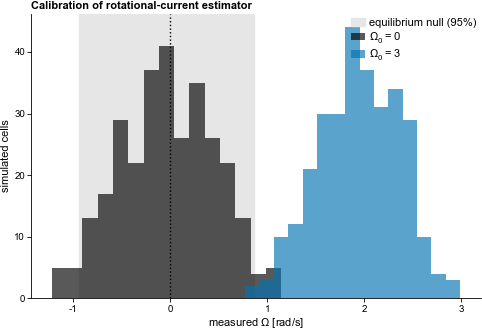

In [4]:
N_CALIBRATION = 300
POSITIVE_CONTROL = 3.0

omega_samples = np.zeros((N_CALIBRATION, 2))
for seed in range(N_CALIBRATION):
    omega_samples[seed, 0] = areal_current(
        simulate_rotating_condensate(omega0=0.0, seed=seed)
    )
    omega_samples[seed, 1] = areal_current(
        simulate_rotating_condensate(omega0=POSITIVE_CONTROL, seed=seed)
    )

omega_equilibrium = omega_samples[:, 0]
omega_rotating = omega_samples[:, 1]
null_omega_band = np.nanpercentile(omega_equilibrium, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.axvspan(*null_omega_band, color="0.9", label="equilibrium null (95%)")
ax.axvline(0, color="k", ls=":")
ax.hist(omega_equilibrium, bins=15, alpha=0.65, label=r"$\Omega_0=0$")
ax.hist(omega_rotating, bins=15, alpha=0.65, label=rf"$\Omega_0={POSITIVE_CONTROL:g}$")
ax.set_xlabel(r"measured $\Omega$ [rad/s]")
ax.set_ylabel("simulated cells")
ax.set_title("Calibration of rotational-current estimator")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22156/3989108188.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


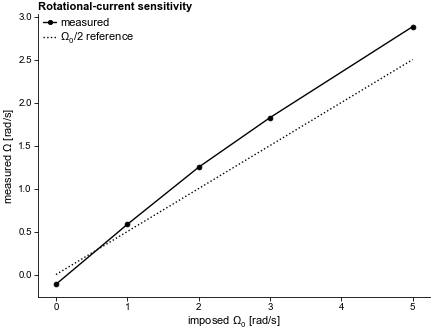

In [5]:
OMEGA_GRID = np.array([0.0, 1.0, 2.0, 3.0, 5.0])
N_SWEEP = 30
measured_omega = []

for imposed_omega in OMEGA_GRID:
    values = np.array([
        areal_current(
            simulate_rotating_condensate(omega0=imposed_omega, seed=seed)
        )
        for seed in range(N_SWEEP)
    ])
    measured_omega.append(np.nanmean(values))

measured_omega = np.asarray(measured_omega)

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.plot(OMEGA_GRID, measured_omega, "o-", label="measured")
ax.plot(OMEGA_GRID, OMEGA_GRID / 2.0, "k:", label=r"$\Omega_0/2$ reference")
ax.set_xlabel(r"imposed $\Omega_0$ [rad/s]")
ax.set_ylabel(r"measured $\Omega$ [rad/s]")
ax.set_title("Rotational-current sensitivity")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4. Apply the rotational-current test to experimental data

One $\Omega$ estimate is calculated per independently analysed cell/focus. Condition means are reported with 95% Student-$t$ confidence intervals and tested against zero with two-sided one-sample $t$-tests.

As in the divergence notebook, Rad51 input fields are segmented into focus-level observations using `segment_foci()` before the current estimator is applied.


In [6]:
def load_trajectory_file(path: Path):
    """Load a whitespace-separated trajectory file as ``id, x, y, time``.

    Malformed files return ``None`` so a single bad input file does not stop the
    complete analysis. Additional columns are ignored.
    """
    try:
        data = np.genfromtxt(path)
    except (OSError, ValueError):
        return None

    if data.ndim != 2 or data.shape[1] < 4:
        return None
    return data[:, :4]


def iter_cells(condition: str):
    """Yield independently analysed cells/foci for one experimental condition.

    Rad51 files are treated as multi-focus fields and segmented with the same
    ``segment_foci`` routine as the main publication analysis. All other input
    files are treated as one cell/focus per file.
    """
    subdirectory, pattern, _ = DATASETS[condition]
    directory = DATA_ROOT / subdirectory
    files = sorted(directory.glob(pattern))
    files = [
        path for path in files
        if "2Foci" not in path.name and "2Cells" not in path.name
    ]

    for path in files:
        data = load_trajectory_file(path)
        if data is None:
            continue

        if condition in SEGMENT_DATASETS:
            for cell in segment_foci(data):
                if len(cell) >= MIN_TOTAL:
                    yield cell
        elif len(data) >= MIN_TOTAL:
            yield data


In [7]:
def summarize_rotation_by_condition():
    """Calculate per-cell angular drifts and condition-level summary statistics."""
    results = {}
    print(f"{'condition':14s} {'n':>4s} {'Omega [rad/s]':>14s} {'95% CI':>20s} {'p':>8s}")

    for condition in DATASETS:
        values = np.array([areal_current(cell) for cell in iter_cells(condition)])
        values = values[np.isfinite(values)]
        n = len(values)
        if n < 2:
            raise ValueError(f"{condition} has only {n} valid cell(s); at least two are required.")

        mean_omega = float(np.mean(values))
        se = float(np.std(values, ddof=1) / np.sqrt(n))
        ci = tuple(stats.t.interval(0.95, n - 1, loc=mean_omega, scale=se))
        pvalue = float(stats.ttest_1samp(values, 0.0).pvalue)
        results[condition] = {
            "n": n,
            "mean": mean_omega,
            "ci": ci,
            "pvalue": pvalue,
            "values": values,
        }
        print(
            f"{PRETTY_NAMES[condition]:14s} {n:4d} {mean_omega:+14.3f} "
            f"[{ci[0]:+.3f}, {ci[1]:+.3f}] {pvalue:8.3g}"
        )

    return results


experimental_rotation = summarize_rotation_by_condition()


condition         n  Omega [rad/s]               95% CI        p
Rad52 (1 DSB)    27         -0.644 [-1.357, +0.070]   0.0752
Rad52 (2 DSB)    14         +0.009 [-0.579, +0.597]    0.973
Rad52-SUMO       12         -0.024 [-2.486, +2.438]    0.983
Rad51            41         -0.115 [-0.542, +0.312]    0.589
Rfa1             26         +0.329 [-0.600, +1.257]    0.472


/var/folders/kp/rpw6x9gx71ncgf2hj3y5qc080000gn/T/ipykernel_22156/832646738.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


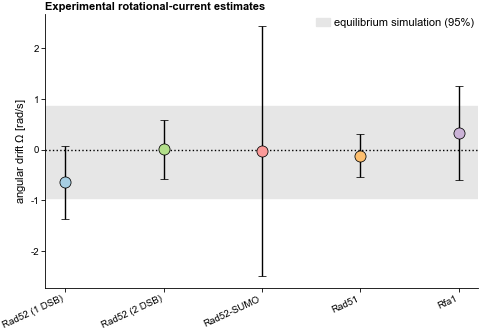

In [8]:
conditions = list(DATASETS)
colors = plt.cm.Paired(np.arange(0, 2 * len(conditions), 2))

fig, ax = plt.subplots(figsize=(5.0, 3.5))
ax.axhspan(*null_omega_band, color="0.9", label="equilibrium simulation (95%)")

for i, (condition, color) in enumerate(zip(conditions, colors)):
    result = experimental_rotation[condition]
    lower = result["mean"] - result["ci"][0]
    upper = result["ci"][1] - result["mean"]
    ax.errorbar(
        i,
        result["mean"],
        yerr=[[lower], [upper]],
        fmt="o",
        ms=8,
        mec="k",
        ecolor="k",
        capsize=3,
        color=color,
    )

ax.axhline(0, color="k", ls=":")
ax.set_xticks(range(len(conditions)), [PRETTY_NAMES[c] for c in conditions], rotation=25, ha="right")
ax.set_ylabel(r"angular drift $\Omega$ [rad/s]")
ax.set_title("Experimental rotational-current estimates")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Notes on interpretation

- A mean $\Omega$ compatible with zero does not prove detailed balance; it means this rotational statistic does not detect a persistent net circulation.
- The estimator is intentionally insensitive to overall translation by centering each trajectory independently. Consequently it measures circulation about each track's local mean rather than motion about an externally estimated common focus centre.
- Radial source–sink currents need not generate a rotational signal. Those are assessed separately in `divergence_test.ipynb`.
